# 📊 Exploratory Data Analysis (EDA) - ID Card & Passport Dataset (YOLO Segment)

Notebook này thực hiện phân tích tổng quan và trực quan hóa tập dữ liệu giấy tờ tùy thân (`ID-card-1`):
1. **Tổng quan Dataset & Cấu trúc Thư mục** (Train / Validation / Test splits).
2. **Phân tích Phân bố Lớp (Class Distribution)**: Đếm số lượng instance của từng loại giấy tờ tùy thân.
3. **Phân tích Kích thước & DPI của Ảnh**: Khảo sát Width, Height, Aspect Ratio và thông số DPI.
4. **Trực quan hóa Ảnh Mẫu kèm Bounding Box & Polygon**: Hiển thị viền phân đoạn Polygon và nhãn phân loại.

In [5]:
import sys
import os
# Ensure venv site-packages is available
venv_site = r"C:\Users\Admin\HUIT - Học Tập\Năm 3\DocU\venv\Lib\site-packages"
if os.path.exists(venv_site) and venv_site not in sys.path:
    sys.path.insert(0, venv_site)

import glob
import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Thiet lap cau hinh hien thi do thi
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print("Da import thanh cong cac thu vien can thiet!")

Da import thanh cong cac thu vien can thiet!


## 1. Load Cấu Hình Dataset từ `data.yaml`

In [6]:
# Duong dan toi thu muc dataset va file data.yaml
BASE_DIR = r'C:\Users\Admin\HUIT - Học Tập\Năm 3\DocU'
DATASET_DIR = os.path.join(BASE_DIR, 'data', 'raw', 'ID-card-1')
YAML_PATH = os.path.join(DATASET_DIR, 'data.yaml')

print('Duong dan Dataset:', DATASET_DIR)
print('Duong dan YAML:', YAML_PATH)

with open(YAML_PATH, 'r', encoding='utf-8') as f:
    data_cfg = yaml.safe_load(f)

class_names = data_cfg['names']
num_classes = data_cfg['nc']

print('Tong so lop doi tuong:', num_classes)
print('Danh sach cac lop:', class_names)

Duong dan Dataset: C:\Users\Admin\HUIT - Học Tập\Năm 3\DocU\data\raw\ID-card-1
Duong dan YAML: C:\Users\Admin\HUIT - Học Tập\Năm 3\DocU\data\raw\ID-card-1\data.yaml
Tong so lop doi tuong: 7
Danh sach cac lop: ['CCCD_BACK', 'CCCD_FRONT', 'CHIP_BACK', 'CHIP_FRONT', 'CMND_BACK', 'CMND_FRONT', 'PASSPORT']


## 2. Thống Kê Số Lượng Ảnh & Instance Phân Bổ Theo Tập (Train/Val/Test)

In [7]:
splits = ['train', 'valid', 'test']
split_stats = []
image_records = []
label_records = []

for split in splits:
    img_dir = os.path.join(DATASET_DIR, split, 'images')
    lbl_dir = os.path.join(DATASET_DIR, split, 'labels')
    
    img_files = glob.glob(os.path.join(img_dir, '*.[jJ][pP][gG]')) + \
                glob.glob(os.path.join(img_dir, '*.[jJ][pP][eE][gG]')) + \
                glob.glob(os.path.join(img_dir, '*.[pP][nN][gG]'))
    
    lbl_files = glob.glob(os.path.join(lbl_dir, '*.txt'))
    
    split_stats.append({
        'Split': split.capitalize(),
        'So Luong Anh': len(img_files),
        'So Luong Label TXT': len(lbl_files)
    })
    
    for img_path in img_files:
        basename = os.path.basename(img_path)
        lbl_path = os.path.join(lbl_dir, os.path.splitext(basename)[0] + '.txt')
        
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                dpi = img.info.get('dpi', (None, None))
                
            image_records.append({
                'split': split.capitalize(),
                'filename': basename,
                'filepath': img_path,
                'width': w,
                'height': h,
                'aspect_ratio': round(w / h, 3),
                'dpi_x': dpi[0] if dpi else None,
                'dpi_y': dpi[1] if dpi else None
            })
        except Exception:
            pass

        if os.path.exists(lbl_path):
            with open(lbl_path, 'r', encoding='utf-8') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) > 0:
                        cls_id = int(parts[0])
                        cls_name = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
                        label_records.append({
                            'split': split.capitalize(),
                            'filename': basename,
                            'class_id': cls_id,
                            'class_name': cls_name,
                            'num_points': (len(parts) - 1) // 2
                        })

df_splits = pd.DataFrame(split_stats)
df_images = pd.DataFrame(image_records)
df_labels = pd.DataFrame(label_records)

print('TONG QUAN PHAN BO TAP DU LIEU:')
display(df_splits)

TONG QUAN PHAN BO TAP DU LIEU:


,Split,So Luong Anh,So Luong Label TXT
0,Train,2928,2928
1,Valid,132,132
2,Test,62,62


## 3. Trực Quan Hóa Phân Bổ Tỷ Lệ Tập Dữ Liệu & Kích Thước Ảnh (Width x Height, DPI)

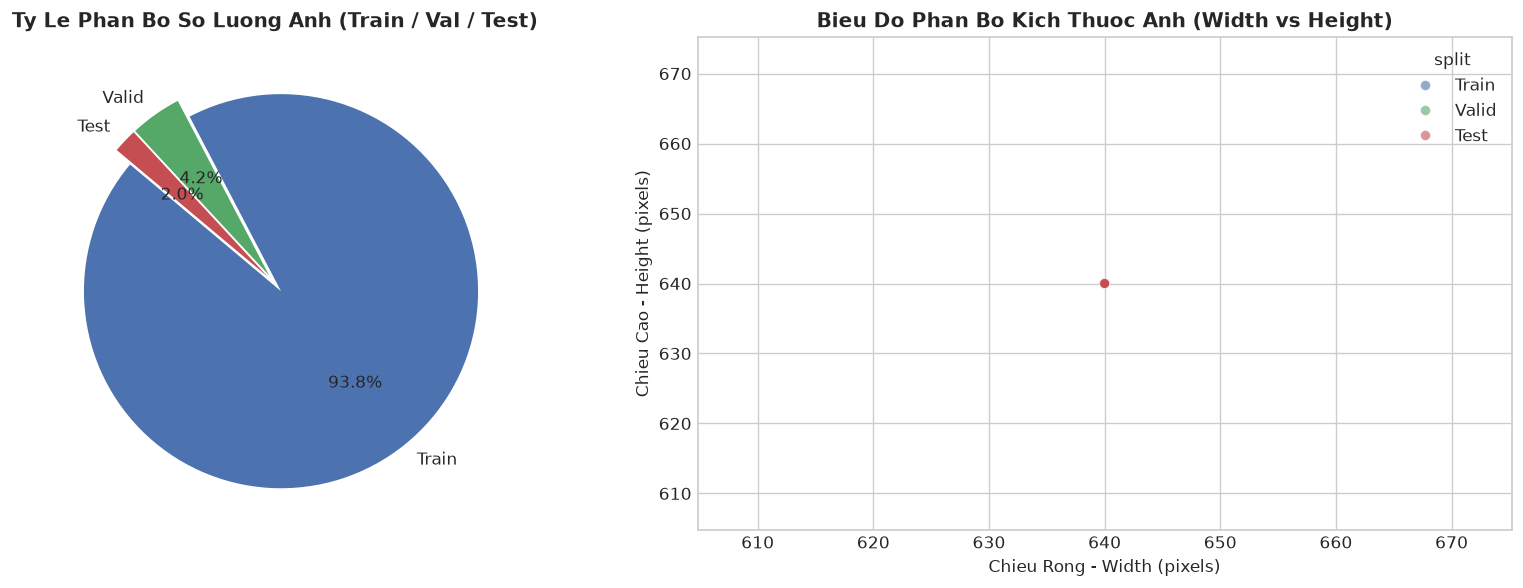

THONG KE CHI TIET KICH THUOC VA DPI ANH:


,width,height,aspect_ratio
count,3122.0,3122.0,3122.0
mean,640.0,640.0,1.0
std,0.0,0.0,0.0
min,640.0,640.0,1.0
25%,640.0,640.0,1.0
50%,640.0,640.0,1.0
75%,640.0,640.0,1.0
max,640.0,640.0,1.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4C72B0', '#55A868', '#C44E52']
axes[0].pie(df_splits['So Luong Anh'], labels=df_splits['Split'], autopct='%1.1f%%', colors=colors, startangle=140, explode=(0.05, 0.05, 0.05))
axes[0].set_title('Ty Le Phan Bo So Luong Anh (Train / Val / Test)', fontsize=12, fontweight='bold')

sns.scatterplot(data=df_images, x='width', y='height', hue='split', alpha=0.6, palette=colors, ax=axes[1])
axes[1].set_title('Bieu Do Phan Bo Kich Thuoc Anh (Width vs Height)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Chieu Rong - Width (pixels)')
axes[1].set_ylabel('Chieu Cao - Height (pixels)')

plt.tight_layout()
plt.show()

print('THONG KE CHI TIET KICH THUOC VA DPI ANH:')
display(df_images[['width', 'height', 'aspect_ratio', 'dpi_x', 'dpi_y']].describe())

## 4. Phân Tích Số Lượng Instance Các Lớp (Class Distribution)

C:\Users\Admin\AppData\Local\Temp\ipykernel_12672\2065873574.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_labels, y='class_name', order=class_order, palette='viridis')


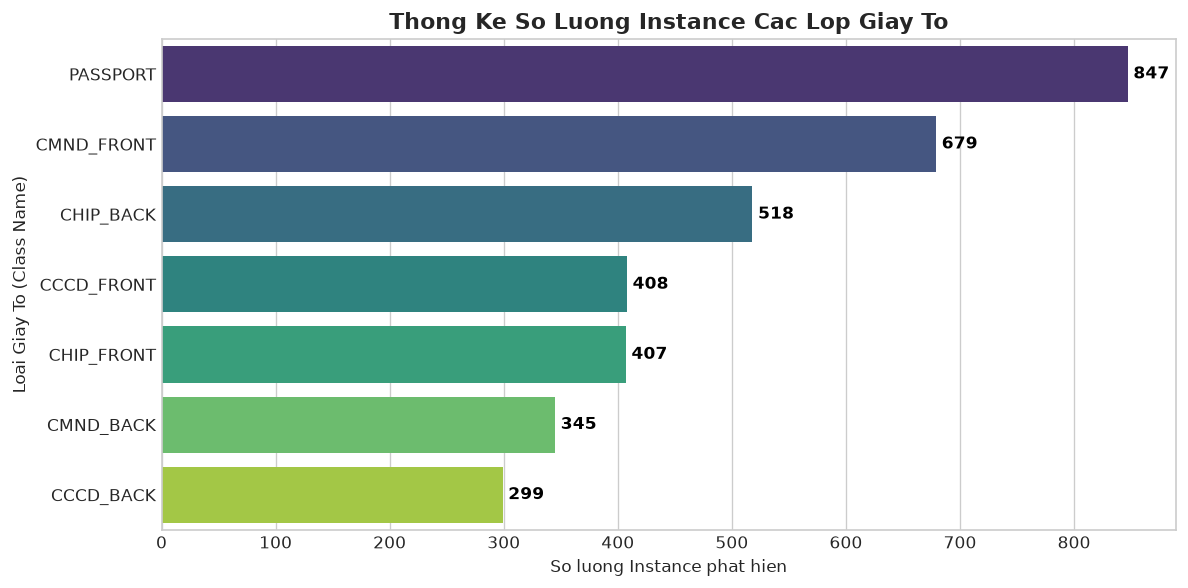

TONG SO LUONG INSTANCE THEO TUNG LOP:


,Tong Instance
class_name,
PASSPORT,847
CMND_FRONT,679
CHIP_BACK,518
CCCD_FRONT,408
CHIP_FRONT,407
CMND_BACK,345
CCCD_BACK,299


In [9]:
plt.figure(figsize=(10, 5))
class_order = df_labels['class_name'].value_counts().index

ax = sns.countplot(data=df_labels, y='class_name', order=class_order, palette='viridis')
plt.title('Thong Ke So Luong Instance Cac Lop Giay To', fontsize=13, fontweight='bold')
plt.xlabel('So luong Instance phat hien')
plt.ylabel('Loai Giay To (Class Name)')

for p in ax.patches:
    w_val = p.get_width()
    ax.annotate(f'{int(w_val)}', (w_val + 5, p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

print('TONG SO LUONG INSTANCE THEO TUNG LOP:')
display(df_labels['class_name'].value_counts().to_frame().rename(columns={'count': 'Tong Instance'}))

## 5. Trực Quan Hóa Ảnh Mẫu Kèm Viền Polygon & Nhãn Phân Loại

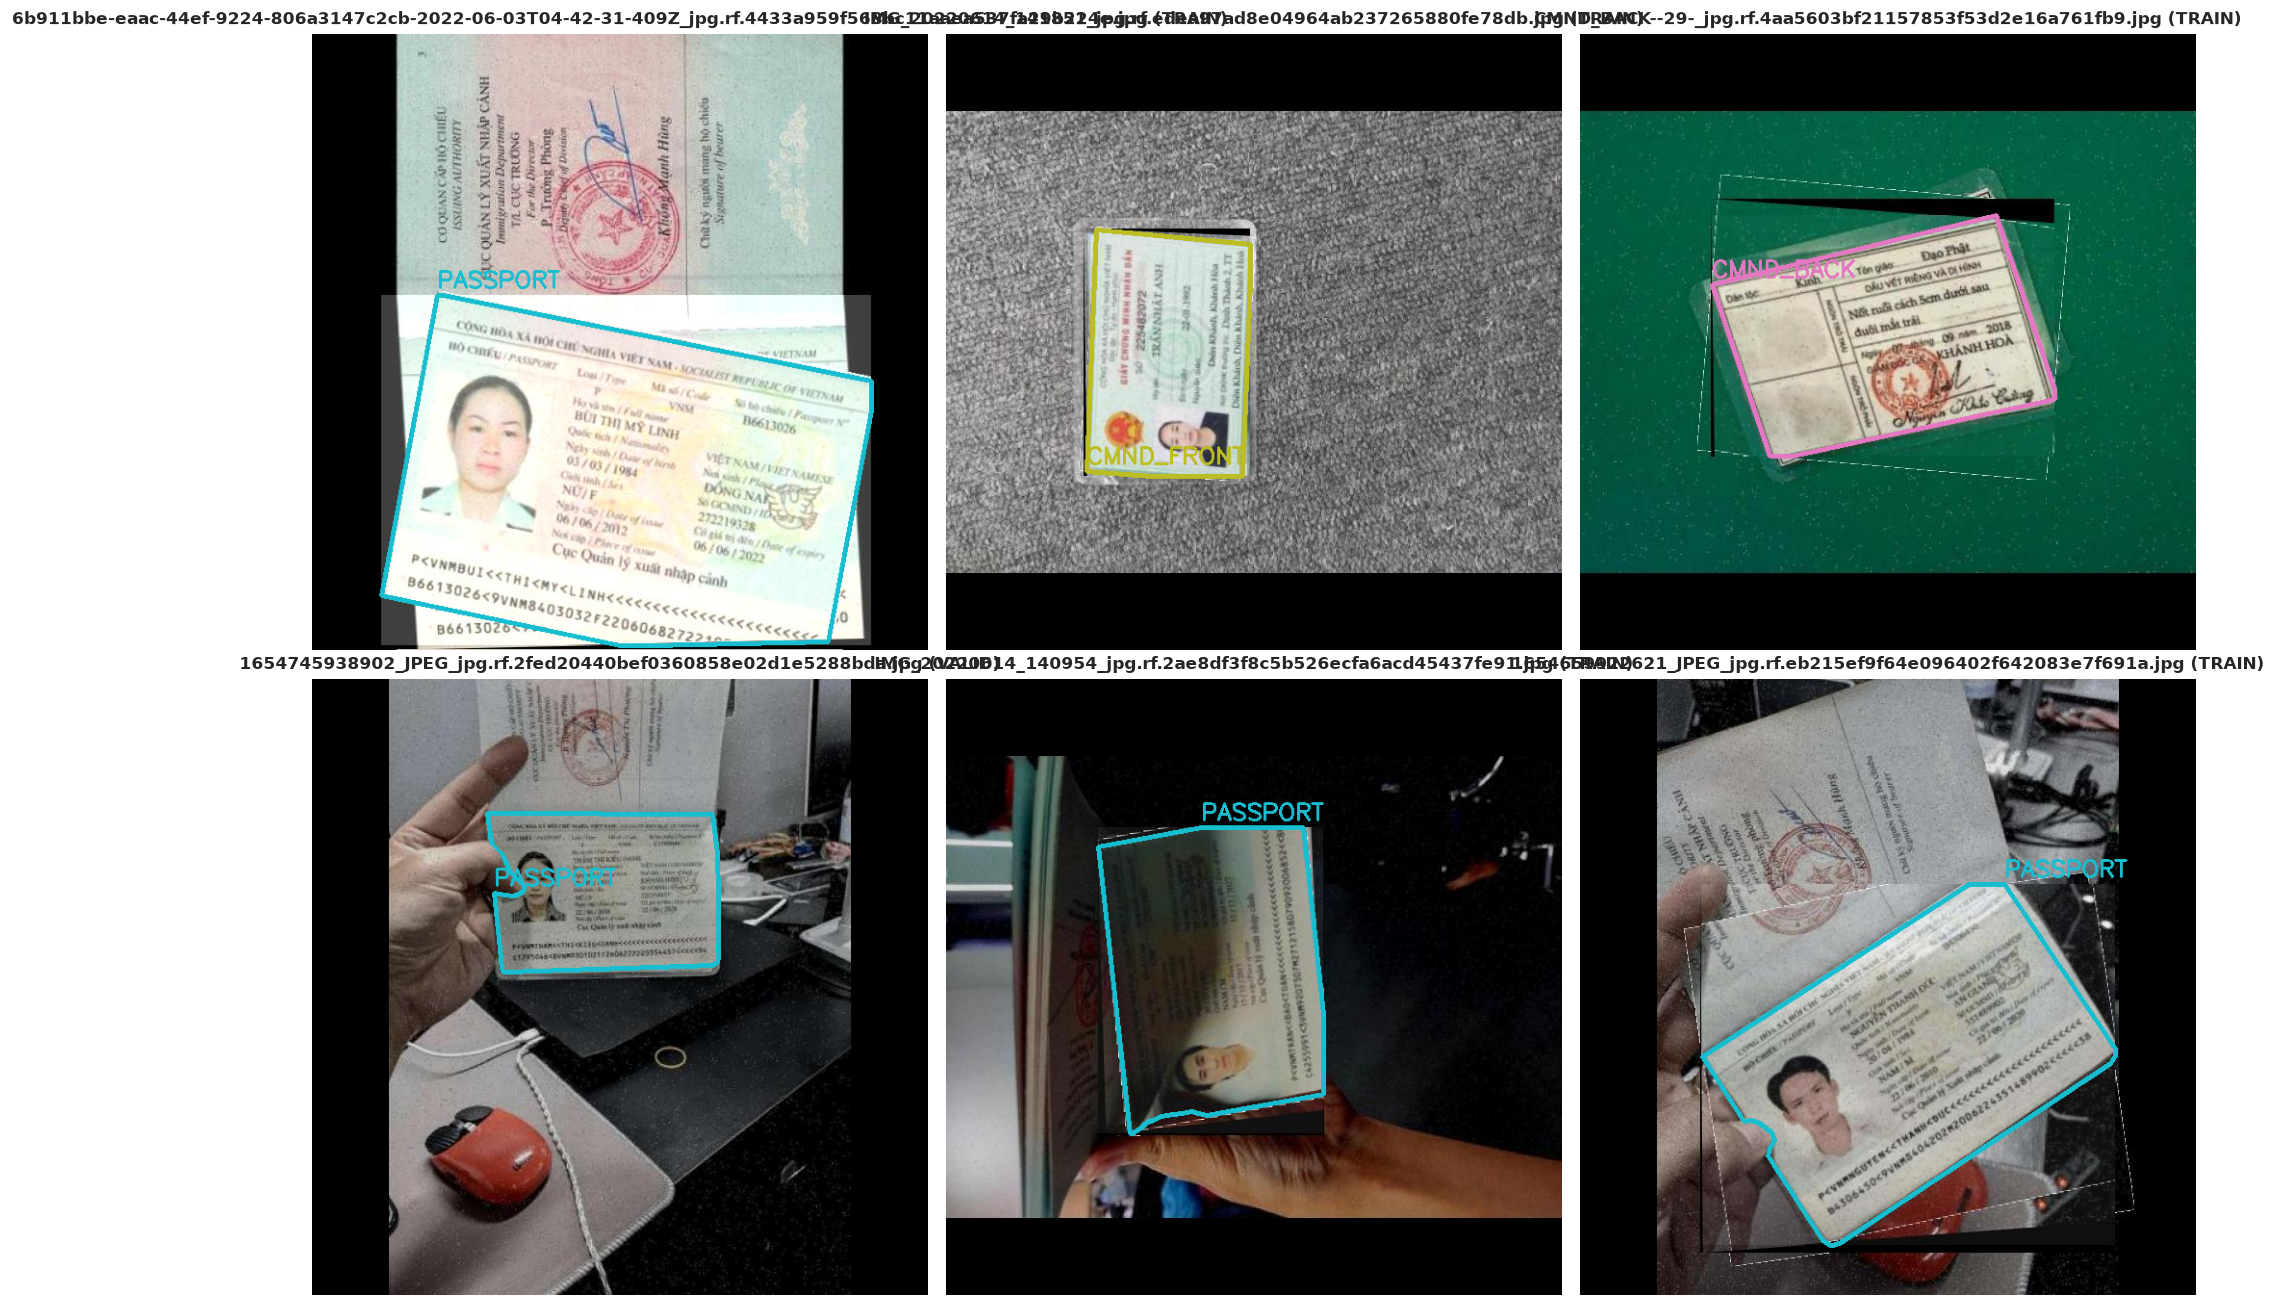

: 

: 

In [ ]:
def visualize_sample_segmentations(df_imgs, df_lbls, num_samples=6):
    # Loại bỏ random_state để mỗi lần chạy sẽ hiển thị ngẫu nhiên các ảnh khác nhau
    sample_records = df_imgs.sample(min(num_samples, len(df_imgs)))
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 11))
    axes = axes.flatten()
    
    cmap = plt.get_cmap('tab10', len(class_names))
    colors = [tuple(int(c * 255) for c in cmap(i)[:3]) for i in range(len(class_names))]
    
    for i, (_, row) in enumerate(sample_records.iterrows()):
        img_path = row['filepath']
        split_name = row['split'].lower()
        basename = row['filename']
        
        # Sửa lỗi cv2.imread không đọc được đường dẫn chứa tiếng Việt (unicode) trên Windows
        img = cv2.imdecode(np.fromfile(img_path, dtype=np.uint8), cv2.IMREAD_COLOR)
        if img is None:
            print(f"Lỗi: Không thể đọc ảnh {basename}")
            continue
            
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        
        lbl_path = os.path.join(DATASET_DIR, split_name, 'labels', os.path.splitext(basename)[0] + '.txt')
        
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r', encoding='utf-8') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls_id = int(parts[0])
                        coords = np.array([float(x) for x in parts[1:]]).reshape(-1, 2)
                        
                        pts = (coords * np.array([w, h])).astype(np.int32)
                        color = colors[cls_id % len(colors)]
                        
                        cv2.polylines(img, [pts], isClosed=True, color=color, thickness=4)
                        label_text = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
                        pt_text = tuple(pts[0])
                        cv2.putText(img, label_text, (pt_text[0], max(25, pt_text[1] - 8)),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
        
        axes[i].imshow(img)
        axes[i].set_title(f'{basename} ({split_name.upper()})', fontsize=10, fontweight='bold')
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

visualize_sample_segmentations(df_images, df_labels, num_samples=6)